# Deterministic forecast evaluation

This notebook shows how to use `ForecastPerformance` to evaluate **deterministic
(point) forecasts** with a suite of skill metrics.  
We generate synthetic daily reference data and two simple forecasts:
* **persistence** – yesterday's observation as today's forecast;
* **noisy model** – the reference plus small Gaussian noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from performance import ForecastPerformance, Results
from performance import rmse, mae, bias, relative_bias, nse, kge, pearson

## 1  Synthetic data

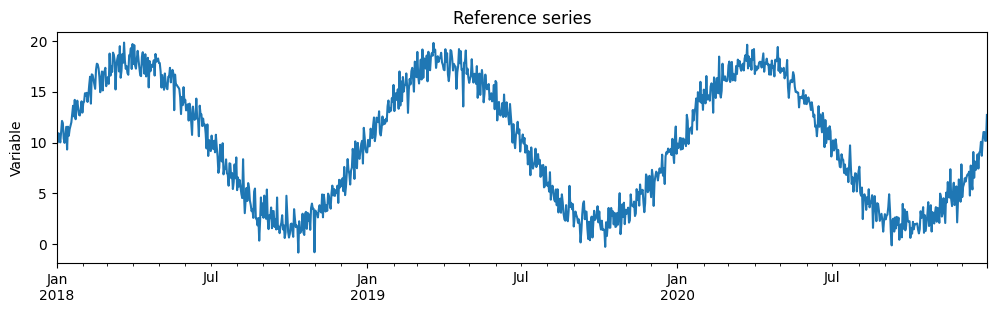

In [2]:
rng = np.random.default_rng(0)

dates = pd.date_range("2018-01-01", periods=365 * 3, freq="D")
t = np.arange(len(dates))

# Sinusoidal seasonal cycle + white noise
reference = pd.Series(
    10 + 8 * np.sin(2 * np.pi * t / 365) + rng.normal(0, 1, len(t)),
    index=dates,
    name="Reference",
)

reference.plot(figsize=(12, 3), title="Reference series", ylabel="Variable");

## 2  Build forecasts

Both forecasts are added as **simple** (point) simulations.  
The column index must be a `pd.Index` with `name="Leadtime"` containing
the leadtime expressed as a `pd.Timedelta`.

In [3]:
fp = ForecastPerformance(reference)

# Noisy model: reference + small Gaussian noise
noisy_model = pd.DataFrame(
    (reference + rng.normal(0, 0.5, len(dates))).values,
    index=dates,
    columns=pd.Index([pd.Timedelta("0D")], name="Leadtime"),
)

# Persistence
persistence = fp.get_persistence(pd.timedelta_range('0D', '10D', freq='1D'))

fp.add_by_production_date(persistence, name="persistence")
fp.add_by_production_date(noisy_model, name="noisy_model")

print("Leadtimes:")
display(fp.leadtimes())

Leadtimes:


,persistence,noisy_model
Leadtime,,
0 days,True,True
1 days,True,False
2 days,True,False
3 days,True,False
4 days,True,False
5 days,True,False
6 days,True,False
7 days,True,False
8 days,True,False


## 3  Compute skill metrics

In [4]:
metrics = {
    "RMSE":          rmse,
    "MAE":           mae,
    "Bias":          bias,
    "Relative bias": relative_bias,
    "NSE":           nse,
    "KGE":           kge,
    "Pearson r":     pearson,
}

rows = []
for name in fp.simulations.keys():
    row = {"Simulation": name}
    for metric_name, fn in metrics.items():
        row[metric_name] = round(fp.deterministic(fn, name), 4)
    rows.append(row)

pd.DataFrame(rows).set_index("Simulation")

ValueError: operands could not be broadcast together with shapes (1095,) (12045,) 

## 4  Accumulate results with `Results`

`Results` is a lightweight helper that collects scalar values keyed by
user-defined fields and converts them to a pivot `DataFrame`.

In [ ]:
results = Results("Simulation", "Metric")

for name in fp.names:
    for metric_name, fn in metrics.items():
        results.append(
            Simulation=name,
            Metric=metric_name,
            Value=fp.deterministic(fn, name),
        )

results.to_pandas(index=["Simulation"], columns=["Metric"]).round(4)

## 5  Multiple lead times

Pass a DataFrame with multiple leadtime columns to evaluate how skill
degrades with increasing lead time.

In [ ]:
# Create a 4-leadtime forecast: each step adds noise proportional to leadtime
leadtimes = [pd.Timedelta(f"{d}D") for d in range(4)]
frames = []
for lt in leadtimes:
    noise = rng.normal(0, 1 + lt.days * 0.5, len(dates))
    col = pd.DataFrame(
        (reference + noise).values,
        index=dates,
        columns=pd.MultiIndex.from_tuples([(lt,)], names=["Leadtime"]),
    )
    frames.append(col)

multi_lt_df = pd.concat(frames, axis=1)
fp.add_by_production_date(multi_lt_df, name="multi_lt")

# Evaluate RMSE at each leadtime
rmse_values = {
    str(lt): fp.deterministic(rmse, "multi_lt", leadtime=lt)
    for lt in leadtimes
}
print("RMSE by leadtime:")
for lt, val in rmse_values.items():
    print(f"  {lt:>4s}: {val:.3f}")

## 6  Visualise forecasts with `plot()`

In [ ]:
# Pick 6 production dates for illustration
prod_dates = dates[::180][:6]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, name in zip(axes, ["persistence", "noisy_model"]):
    fp.plot(name, production_dates=prod_dates, legend=True, ax=ax)
    ax.set_title(name)

fig.tight_layout();